# Reconhecimento de Padrões

Grupo:

*   João
*   Marcus
* Priscilla Mayumi Tenguan

**USP - SIN5007--2026**



## Importação de Dados

Dataset escolhido: https://archive.ics.uci.edu/dataset/2/adult

In [1]:
# CÓDIGO ORIGINAL FORNECIDO:

from ucimlrepo import fetch_ucirepo

# fetch dataset
adult = fetch_ucirepo(id=2)

# data (as pandas dataframes)
X = adult.data.features
y = adult.data.targets

# metadata
print(adult.metadata)

# variable information
print(adult.variables)


{'uci_id': 2, 'name': 'Adult', 'repository_url': 'https://archive.ics.uci.edu/dataset/2/adult', 'data_url': 'https://archive.ics.uci.edu/static/public/2/data.csv', 'abstract': 'Predict whether annual income of an individual exceeds $50K/yr based on census data. Also known as "Census Income" dataset. ', 'area': 'Social Science', 'tasks': ['Classification'], 'characteristics': ['Multivariate'], 'num_instances': 48842, 'num_features': 14, 'feature_types': ['Categorical', 'Integer'], 'demographics': ['Age', 'Income', 'Education Level', 'Other', 'Race', 'Sex'], 'target_col': ['income'], 'index_col': None, 'has_missing_values': 'yes', 'missing_values_symbol': 'NaN', 'year_of_dataset_creation': 1996, 'last_updated': 'Tue Sep 24 2024', 'dataset_doi': '10.24432/C5XW20', 'creators': ['Barry Becker', 'Ronny Kohavi'], 'intro_paper': None, 'additional_info': {'summary': "Extraction was done by Barry Becker from the 1994 Census database.  A set of reasonably clean records was extracted using the fol

##Análise Exploratória

Requirement mínimo:

Descrição do dataset: o que é, quais são as classes, número de
instâncias, número de características (tirando campos id e classificação),
número de instâncias sem nenhum missing value
• Quantas características de cada tipo (nominais, intervalares, etc.) (se
poucas, mencione quais são)

In [2]:
# Importações necessárias / bibliotecas
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

In [3]:
# =================================================================
# INFORMAÇÕES GERAIS, VISUALIZAÇÃO E CARACTERÍSTICAS
# =================================================================

# 1. Juntar as features (X) e targets (y) num único DataFrame
df = pd.concat([X, y], axis=1)

# Pegando a quantidade de linhas e colunas
linhas = df.shape[0]
colunas = df.shape[1]

print(f"O dataset possui {linhas} linhas e {colunas} colunas.\n")

# 2. Features (variáveis independentes)
features = X.columns.tolist()
qtd_features = len(features)


print(f"\n São {qtd_features} features:")
for feature in features:
    print(f"- {feature}")

# 3. Listando o Target (variável dependente / classe alvo)
targets = y.columns.tolist()

print(f"\nTarget (variável dependente):")
for target in targets:
    print(f"- {target}")

print("\n--- Sample tabela ---")
display(df.head())

O dataset possui 48842 linhas e 15 colunas.


 São 14 features:
- age
- workclass
- fnlwgt
- education
- education-num
- marital-status
- occupation
- relationship
- race
- sex
- capital-gain
- capital-loss
- hours-per-week
- native-country

Target (variável dependente):
- income

--- Sample tabela ---


,age,workclass,fnlwgt,education,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country,income
0,39,State-gov,77516,Bachelors,13,Never-married,Adm-clerical,Not-in-family,White,Male,2174,0,40,United-States,<=50K
1,50,Self-emp-not-inc,83311,Bachelors,13,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,13,United-States,<=50K
2,38,Private,215646,HS-grad,9,Divorced,Handlers-cleaners,Not-in-family,White,Male,0,0,40,United-States,<=50K
3,53,Private,234721,11th,7,Married-civ-spouse,Handlers-cleaners,Husband,Black,Male,0,0,40,United-States,<=50K
4,28,Private,338409,Bachelors,13,Married-civ-spouse,Prof-specialty,Wife,Black,Female,0,0,40,Cuba,<=50K


In [4]:
print("--- 1. TIPOS DE DADOS DAS FEATURES ---")
tipos_dados = df.dtypes.value_counts()
print(tipos_dados)

--- 1. TIPOS DE DADOS DAS FEATURES ---
str      9
int64    6
Name: count, dtype: int64


In [5]:
print("\n--- Existem Outliers e missing values ---")

# Calculate the number of instances with any missing values
num_instances_with_missing = df.isnull().any(axis=1).sum()
print(f"Número de instâncias com missing values em qualquer posição: {num_instances_with_missing}\n")

# Analisar dados nao numericos: qual valor e qual frequencia? - aparentemente a biblioteca ucimlrepo já remove alguns outliers e transforma em NaN
colunas_texto = df.select_dtypes(include=['object']).columns

for coluna in colunas_texto:
    print(f"\nFeature: '{coluna}'")
    # dropna=False mostra valores nulos por default (NaN)
    print(df[coluna].value_counts(dropna=False))
    print("-" * 40) #numero da string multiplicado apenas para facilitar leitura do texto com os divisores


--- Existem Outliers e missing values ---
Número de instâncias com missing values em qualquer posição: 1221


Feature: 'workclass'
workclass
Private             33906
Self-emp-not-inc     3862
Local-gov            3136
State-gov            1981
?                    1836
Self-emp-inc         1695
Federal-gov          1432
NaN                   963
Without-pay            21
Never-worked           10
Name: count, dtype: int64
----------------------------------------

Feature: 'education'
education
HS-grad         15784
Some-college    10878
Bachelors        8025
Masters          2657
Assoc-voc        2061
11th             1812
Assoc-acdm       1601
10th             1389
7th-8th           955
Prof-school       834
9th               756
12th              657
Doctorate         594
5th-6th           509
1st-4th           247
Preschool          83
Name: count, dtype: int64
----------------------------------------

Feature: 'marital-status'
marital-status
Married-civ-spouse       22379
Never-m

C:\Users\vinic\AppData\Local\Temp\ipykernel_18936\2696747336.py:8: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  colunas_texto = df.select_dtypes(include=['object']).columns


In [6]:
#O que falta:
#Resumo sobre missing values
#Heatmap / matrix de correl
#boxplot - tem outliers? como é a distribuição?

In [7]:
# =================================================================
# WIP MATRIX DE CORRELAÇÃO (HEATMAP)
# =================================================================


### Prepara??o da Target

Binarizamos a vari?vel alvo para viabilizar correla??es e taxas de classe positiva.
Ap?s a binariza??o, removemos a coluna original da target para evitar duplicidade.


In [8]:
# Prepara??o da target
target_col = y.columns[0]
df[target_col] = df[target_col].astype(str).str.strip().str.replace('.', '', regex=False)
vals = sorted(df[target_col].dropna().unique())
print('Valores da target:', vals)

if '>50K' in vals:
    target_positive = '>50K'
elif '1' in vals:
    target_positive = '1'
else:
    target_positive = vals[-1]

df['_target_bin'] = (df[target_col] == target_positive).astype(int)
df = df.drop(columns=[target_col])

print('Target positiva:', target_positive)
print(df['_target_bin'].value_counts())


Valores da target: ['<=50K', '>50K']
Target positiva: >50K
_target_bin
0    37155
1    11687
Name: count, dtype: int64


### Correla??es e Impactos na Target

Principais achados (base Adult):

- marital-status vs relationship: Cram?r's V ? 0,49 ? associa??o forte, mas n?o redundantes.
- race vs target: Cram?r's V ? 0,10 ? efeito fraco.
- sex vs target: Cram?r's V ? 0,215 ? efeito moderado.
- age vs target: point-biserial ? 0,23 e hours-per-week ? 0,228 ? efeitos moderados.
- Maiores taxas de >50K aparecem em Married-civ-spouse e em Husband/Wife.


In [9]:
# Helpers para correla??o e taxas por grupo
from scipy.stats import chi2_contingency, pointbiserialr

sns.set_theme(style='whitegrid')

def cramers_v(col_a, col_b):
    ct = pd.crosstab(col_a, col_b)
    chi2, p, _, _ = chi2_contingency(ct)
    n = ct.to_numpy().sum()
    phi2 = chi2 / n
    r, k = ct.shape
    phi2corr = max(0, phi2 - ((k - 1) * (r - 1)) / (n - 1))
    rcorr = r - ((r - 1) ** 2) / (n - 1)
    kcorr = k - ((k - 1) ** 2) / (n - 1)
    v = np.sqrt(phi2corr / max(1, min((kcorr - 1), (rcorr - 1))))
    return v, p, ct

def rate_by_group(col):
    return df.groupby(col)['_target_bin'].mean().sort_values()

def plot_rate(series, title, xlabel):
    plt.figure(figsize=(8, 4))
    sns.barplot(x=series.values, y=series.index, orient='h')
    plt.xlabel(xlabel)
    plt.ylabel(series.index.name or "")
    plt.title(title)
    plt.tight_layout()
    plt.show()


In [10]:
# Associa??o entre marital-status e relationship (Cram?r's V)
v, p, ct = cramers_v(df['marital-status'], df['relationship'])
print(f"Cram?r's V: {v:.3f} | p-value: {p:.4g}")
print('Conting?ncia (linhas x colunas):', ct.shape)


Cram?r's V: 0.488 | p-value: 0


Conting?ncia (linhas x colunas): (7, 6)


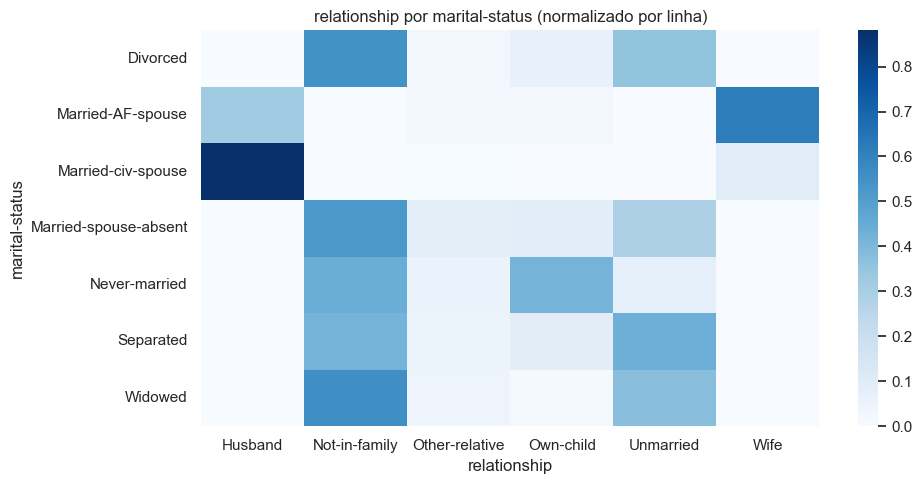

In [11]:
# Heatmap: relationship por marital-status (normalizado por linha)
ct = pd.crosstab(df['marital-status'], df['relationship'])
ct_norm = ct.div(ct.sum(axis=1), axis=0)
plt.figure(figsize=(10, 5))
sns.heatmap(ct_norm, cmap='Blues')
plt.title('relationship por marital-status (normalizado por linha)')
plt.xlabel('relationship')
plt.ylabel('marital-status')
plt.tight_layout()
plt.show()


marital-status
Never-married            0.045480
Separated                0.064706
Widowed                  0.084321
Married-spouse-absent    0.092357
Divorced                 0.101161
Married-AF-spouse        0.378378
Married-civ-spouse       0.446133
Name: _target_bin, dtype: float64


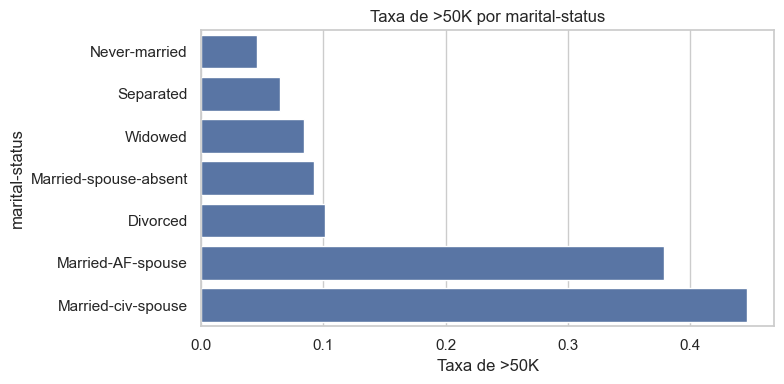

In [12]:
# Impacto de marital-status na target (taxa de >50K)
ms_rate = rate_by_group('marital-status')
print(ms_rate)
plot_rate(ms_rate, 'Taxa de >50K por marital-status', 'Taxa de >50K')


relationship
Own-child         0.014642
Other-relative    0.034529
Unmarried         0.060293
Not-in-family     0.101407
Husband           0.448671
Wife              0.468897
Name: _target_bin, dtype: float64


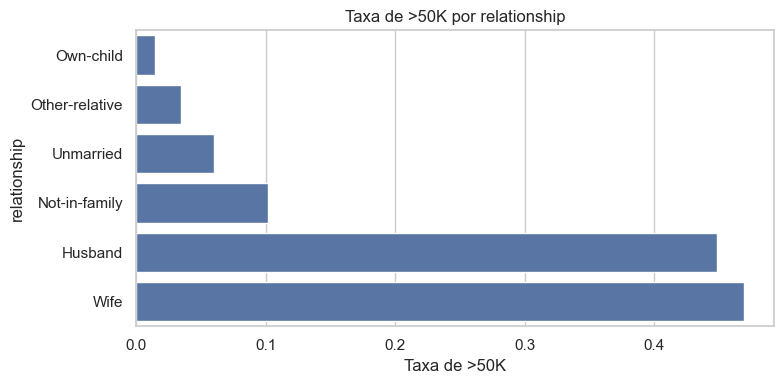

In [13]:
# Impacto de relationship na target (taxa de >50K)
rel_rate = rate_by_group('relationship')
print(rel_rate)
plot_rate(rel_rate, 'Taxa de >50K por relationship', 'Taxa de >50K')


Cram?r's V: 0.099 | p-value: 4.284e-104


race
Amer-Indian-Eskimo    0.117021
Black                 0.120811
Other                 0.123153
White                 0.253987
Asian-Pac-Islander    0.269256
Name: _target_bin, dtype: float64


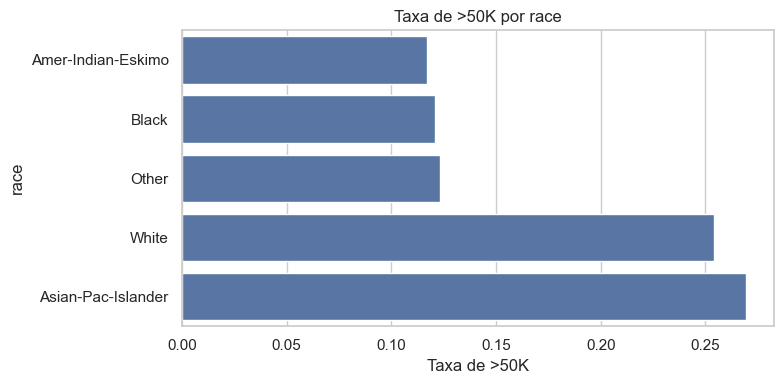

In [14]:
# Impacto de race na target (Cram?r's V + taxa)
v, p, _ = cramers_v(df['race'], df['_target_bin'])
race_rate = rate_by_group('race')
print(f"Cram?r's V: {v:.3f} | p-value: {p:.4g}")
print(race_rate)
plot_rate(race_rate, 'Taxa de >50K por race', 'Taxa de >50K')


Cram?r's V: 0.215 | p-value: 0
sex
Female    0.109251
Male      0.303767
Name: _target_bin, dtype: float64


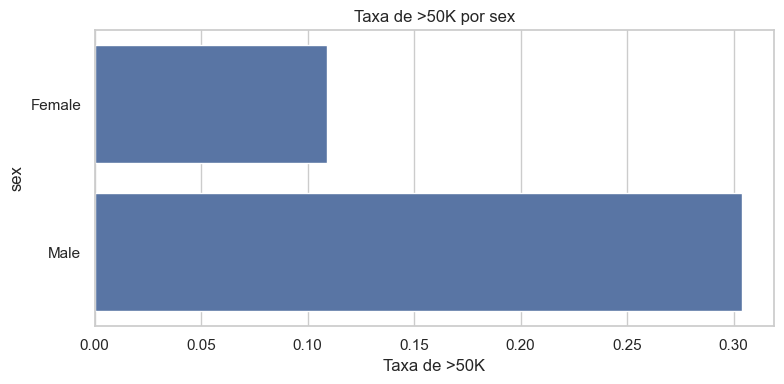

In [15]:
# Impacto de sex na target (Cram?r's V + taxa)
v, p, _ = cramers_v(df['sex'], df['_target_bin'])
sex_rate = rate_by_group('sex')
print(f"Cram?r's V: {v:.3f} | p-value: {p:.4g}")
print(sex_rate)
plot_rate(sex_rate, 'Taxa de >50K por sex', 'Taxa de >50K')


Matriz de correla??o (Pearson) - num?ricas:
                     age    fnlwgt  education-num  capital-gain  capital-loss  \
age             1.000000 -0.076628       0.030940      0.077229      0.056944   
fnlwgt         -0.076628  1.000000      -0.038761     -0.003706     -0.004366   
education-num   0.030940 -0.038761       1.000000      0.125146      0.080972   
capital-gain    0.077229 -0.003706       0.125146      1.000000     -0.031441   
capital-loss    0.056944 -0.004366       0.080972     -0.031441      1.000000   
hours-per-week  0.071558 -0.013519       0.143689      0.082157      0.054467   
_target_bin     0.230369 -0.006339       0.332613      0.223013      0.147554   

                hours-per-week  _target_bin  
age                   0.071558     0.230369  
fnlwgt               -0.013519    -0.006339  
education-num         0.143689     0.332613  
capital-gain          0.082157     0.223013  
capital-loss          0.054467     0.147554  
hours-per-week        1.000000 

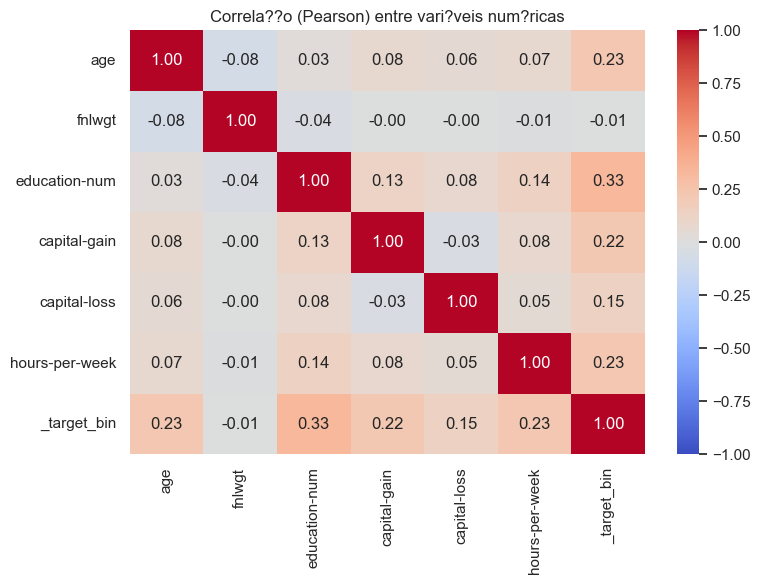

In [16]:
# Correla??o entre vari?veis num?ricas (inclui target bin?ria)
num_cols = df.select_dtypes(include=['number']).columns.tolist()
corr = df[num_cols].corr(method='pearson')
print('Matriz de correla??o (Pearson) - num?ricas:')
print(corr)
plt.figure(figsize=(8, 6))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', vmin=-1, vmax=1)
plt.title('Correla??o (Pearson) entre vari?veis num?ricas')
plt.tight_layout()
plt.show()


Point-biserial: 0.230 | p-value: 0


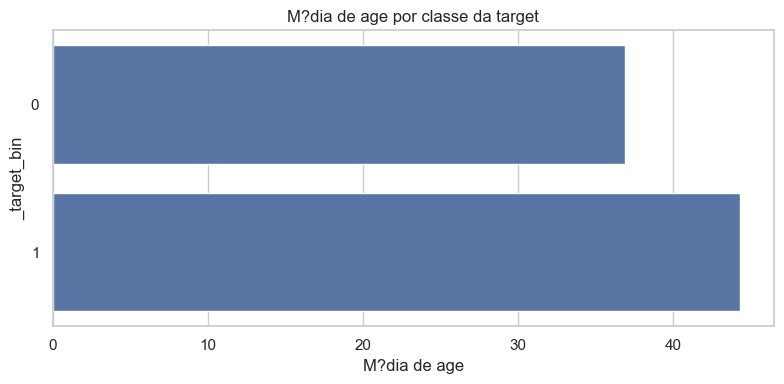

In [17]:
# Correla??o de age com a target (point-biserial + m?dias)
corr, p = pointbiserialr(df['_target_bin'], df['age'])
print(f"Point-biserial: {corr:.3f} | p-value: {p:.4g}")
age_mean = df.groupby('_target_bin')['age'].mean()
plot_rate(age_mean, 'M?dia de age por classe da target', 'M?dia de age')


Point-biserial: 0.228 | p-value: 0


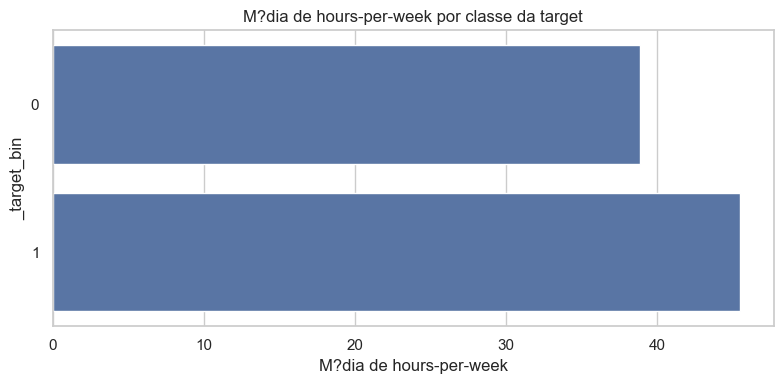

In [18]:
# Correla??o de hours-per-week com a target (point-biserial + m?dias)
corr, p = pointbiserialr(df['_target_bin'], df['hours-per-week'])
print(f"Point-biserial: {corr:.3f} | p-value: {p:.4g}")
hpw_mean = df.groupby('_target_bin')['hours-per-week'].mean()
plot_rate(hpw_mean, 'M?dia de hours-per-week por classe da target', 'M?dia de hours-per-week')


In [19]:
print('### Classifica??o das Vari?veis ###\n')

continuas_razao = []
discretas_ordinais = []
discretas_nominais = []

for feature in df.columns:
    if feature == '_target_bin':
        continue
    if feature in ['age', 'fnlwgt', 'capital-gain', 'capital-loss', 'hours-per-week']:
        continuas_razao.append(feature)
    elif feature in ['education-num', 'education']:
        discretas_ordinais.append(feature)
    elif feature in ['workclass', 'marital-status', 'occupation', 'relationship', 'race', 'sex', 'native-country']:
        discretas_nominais.append(feature)
    else:
        print(f"Warning: Feature '{feature}' not classified.")

print('Cont?nuas (Raz?o):')
for f in continuas_razao:
    print(f"- {f}")

print('\nDiscretas Ordinais:')
for f in discretas_ordinais:
    print(f"- {f}")

print('\nDiscretas Nominais:')
for f in discretas_nominais:
    print(f"- {f}")


### Classifica??o das Vari?veis ###

Cont?nuas (Raz?o):
- age
- fnlwgt
- capital-gain
- capital-loss
- hours-per-week

Discretas Ordinais:
- education
- education-num

Discretas Nominais:
- workclass
- marital-status
- occupation
- relationship
- race
- sex
- native-country


# Feature Engineering

In [20]:
# Ajustes em education / education-num (ordinal)
edu_pairs = df[['education', 'education-num']].drop_duplicates().sort_values('education-num')
edu_nums = edu_pairs['education-num'].to_numpy()
edu_ok = edu_pairs.groupby('education')['education-num'].nunique().eq(1).all() and (edu_nums == np.arange(1, len(edu_pairs) + 1)).all()

if edu_ok:
    df = df.drop(columns=['education'])
else:
    edu_order = df.groupby('education')['education-num'].median().sort_values().index
    edu_map = {e: i + 1 for i, e in enumerate(edu_order)}
    df['education-ord'] = df['education'].map(edu_map)
    df = df.drop(columns=['education', 'education-num'])

print('education vs education-num -> ordinal:', edu_ok)
print(edu_pairs)

# capital-balance e remo??o de capital-gain/capital-loss
df['capital-balance'] = df['capital-gain'] - df['capital-loss']
df = df.drop(columns=['capital-gain', 'capital-loss'])
print('capital-balance criado; capital-gain/loss removidos')


education vs education-num -> ordinal: True
        education  education-num
224     Preschool              1
160       1st-4th              2
56        5th-6th              3
15        7th-8th              4
6             9th              5
77           10th              6
3            11th              7
415          12th              8
2         HS-grad              9
10   Some-college             10
14      Assoc-voc             11
13     Assoc-acdm             12
0       Bachelors             13
5         Masters             14
52    Prof-school             15
20      Doctorate             16
capital-balance criado; capital-gain/loss removidos


In [21]:
# Drop de fnlwgt
if 'fnlwgt' in df.columns:
    df = df.drop(columns=['fnlwgt'])
print('fnlwgt presente:', 'fnlwgt' in df.columns)


fnlwgt presente: False


In [22]:
# Valores ?nicos em colunas categ?ricas selecionadas
for col in ['native-country', 'occupation', 'workclass']:
    if col in df.columns:
        print(f"{col}: {df[col].nunique()} valores ?nicos")


native-country: 42 valores ?nicos
occupation: 15 valores ?nicos
workclass: 9 valores ?nicos


In [23]:
# Label encoding para sex
if 'sex' in df.columns:
    df['sex'] = pd.Categorical(df['sex']).codes
    print('sex codificado (exemplo):')
    print(df['sex'].value_counts().sort_index())


sex codificado (exemplo):


sex
0    16192
1    32650
Name: count, dtype: int64


In [24]:
# Discretiza??o de age em faixas
if 'age' in df.columns:
    bins = [0, 18, 25, 35, 45, 55, 65, 100]
    labels = ['0-18', '19-25', '26-35', '36-45', '46-55', '56-65', '66+']
    df['age_bin'] = pd.cut(df['age'], bins=bins, labels=labels, right=True, include_lowest=True)
    print(df['age_bin'].value_counts().sort_index())
    df = df.drop(columns=['age'])
    print('age removida:', 'age' not in df.columns)


age_bin
0-18      1457
19-25     8170
26-35    12719
36-45    11952
46-55     8296
56-65     4445
66+       1803
Name: count, dtype: int64
age removida: True


In [25]:
# One-Hot Encoding para marital-status, relationship e race
ohe_cols = [c for c in ['marital-status', 'relationship', 'race'] if c in df.columns]
if ohe_cols:
    df = pd.get_dummies(df, columns=ohe_cols, prefix=ohe_cols, drop_first=False)
    print('One-hot aplicado em:', ohe_cols)
    print('Colunas atuais:', len(df.columns))


One-hot aplicado em: ['marital-status', 'relationship', 'race']
Colunas atuais: 27


### Capital-Balance (ap?s Feature Engineering)

A distribui??o ? altamente concentrada em zero, com cauda longa.
A correla??o com a target ? moderada (point-biserial ? 0,214).


count    48842.000000
mean       991.565313
std       7475.549906
min      -4356.000000
25%          0.000000
50%          0.000000
75%          0.000000
max      99999.000000
Name: capital-balance, dtype: float64


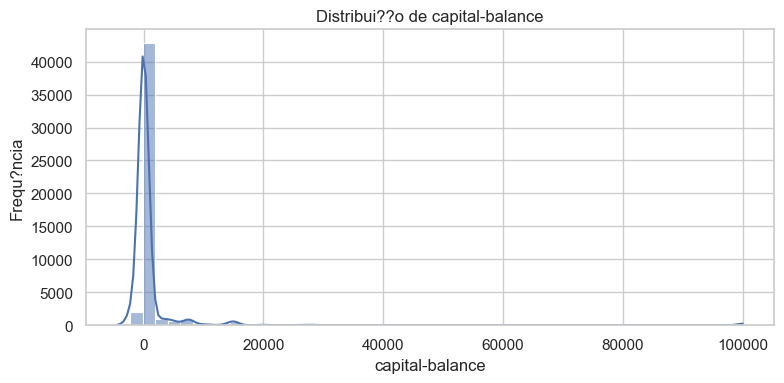

In [26]:
# Distribui??o de capital-balance
print(df['capital-balance'].describe())
plt.figure(figsize=(8, 4))
sns.histplot(df['capital-balance'], bins=50, kde=True)
plt.title('Distribui??o de capital-balance')
plt.xlabel('capital-balance')
plt.ylabel('Frequ?ncia')
plt.tight_layout()
plt.show()


Point-biserial: 0.214 | p-value: 0


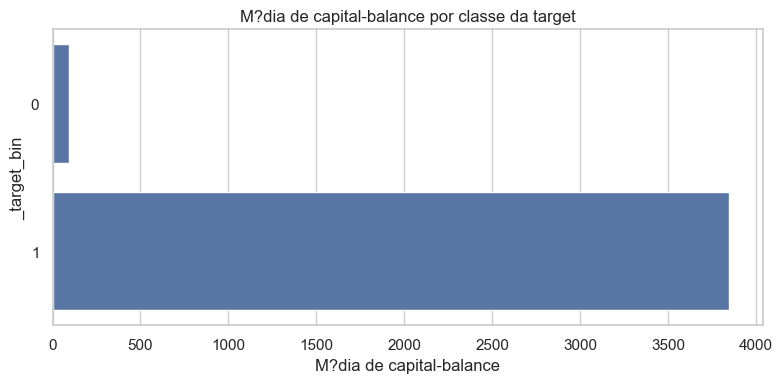

In [27]:
# Correla??o de capital-balance com a target (point-biserial + m?dias)
corr, p = pointbiserialr(df['_target_bin'], df['capital-balance'])
print(f"Point-biserial: {corr:.3f} | p-value: {p:.4g}")
cb_mean = df.groupby('_target_bin')['capital-balance'].mean()
plot_rate(cb_mean, 'M?dia de capital-balance por classe da target', 'M?dia de capital-balance')


In [28]:
# Amostra do dataframe ap?s o feature engineering
df.head()


,workclass,education-num,occupation,sex,hours-per-week,native-country,_target_bin,capital-balance,age_bin,marital-status_Divorced,...,relationship_Not-in-family,relationship_Other-relative,relationship_Own-child,relationship_Unmarried,relationship_Wife,race_Amer-Indian-Eskimo,race_Asian-Pac-Islander,race_Black,race_Other,race_White
0,State-gov,13,Adm-clerical,1,40,United-States,0,2174,36-45,False,...,True,False,False,False,False,False,False,False,False,True
1,Self-emp-not-inc,13,Exec-managerial,1,13,United-States,0,0,46-55,False,...,False,False,False,False,False,False,False,False,False,True
2,Private,9,Handlers-cleaners,1,40,United-States,0,0,36-45,True,...,True,False,False,False,False,False,False,False,False,True
3,Private,7,Handlers-cleaners,1,40,United-States,0,0,46-55,False,...,False,False,False,False,False,False,False,True,False,False
4,Private,13,Prof-specialty,0,40,Cuba,0,0,26-35,False,...,False,False,False,False,True,False,False,True,False,False
